In [ ]:
# !pip install tensorflow

In [1]:
# 1. IMPORT LIBRARIES



import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd


In [5]:
train_df=pd.read_csv("mnist/train.csv")
train_df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
train_df.label.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [7]:
test_df = pd.read_csv("mnist/test.csv")
test_df


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
print("Train data shape: {}\n Test data shape: {}".format(train_df.shape, test_df.shape))


Train data shape: (42000, 785)
 Test data shape: (28000, 784)


In [9]:
X_train = train_df.drop("label", axis = 1)
Y_train = train_df["label"]
X_test = test_df
print(X_train.shape, Y_train.shape, X_test.shape)

(42000, 784) (42000,) (28000, 784)


In [10]:
# Normalization 
# x = x - min(x) / max(x) - min(x)
X_train = X_train/255
X_test = X_test/255


In [11]:

#  CONVERT TO NUMPY
# TensorFlow works best with NumPy arrays

X_train = X_train.values
Y_train = Y_train.values
X_test = X_test.values


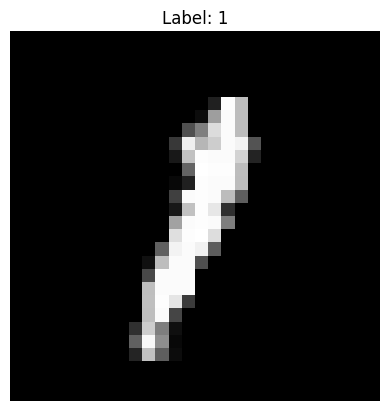

In [12]:


# 6. VISUALIZE RANDOM TRAIN IMAGE
# 

idx = np.random.randint(0, len(X_train))
image = X_train[idx].reshape(28, 28)

plt.imshow(image, cmap='gray')
plt.title(f"Label: {Y_train[idx]}")
plt.axis('off')
plt.show()


In [14]:


# 7. BUILD MLP MODEL (NO CNN)

model = keras.Sequential([
    
    # Input layer (784 pixels)
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    
    # Hidden layer
    keras.layers.Dense(64, activation='relu'),
    
    # Output layer (10 classes)
    keras.layers.Dense(10, activation='softmax')
])

print("\nModel Summary:")
model.summary()


Model Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [15]:
# 8. COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
# 9. TRAIN MODEL

history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1313/1313 [==============================] - 7s 4ms/step - loss: 0.2754 - accuracy: 0.9198
Epoch 2/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.1143 - accuracy: 0.9659
Epoch 3/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0793 - accuracy: 0.9750
Epoch 4/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0602 - accuracy: 0.9818
Epoch 5/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0452 - accuracy: 0.9856
Epoch 6/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0360 - accuracy: 0.9883
Epoch 7/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0305 - accuracy: 0.9895
Epoch 8/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0260 - accuracy: 0.9917
Epoch 9/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.0224 - accuracy: 0.9922
Epoch 10/10
1313/1313 [==============================] - 5s 4ms/step - loss: 0.019

In [17]:
# 10. PREDICT ON TEST DATA

predictions = model.predict(X_test)

# Convert probabilities → final labels
pred_labels = np.argmax(predictions, axis=1)

print("\nFirst 10 Predictions:")
print(pred_labels[:10])


875/875 [==============================] - 2s 2ms/step

First 10 Predictions:
[2 0 9 9 3 7 0 3 0 3]


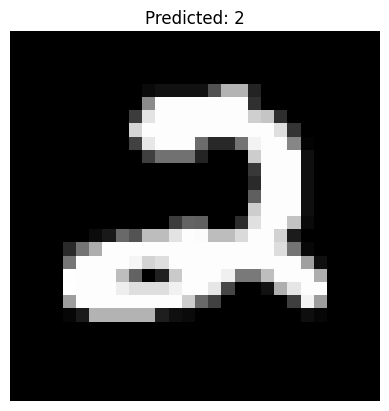

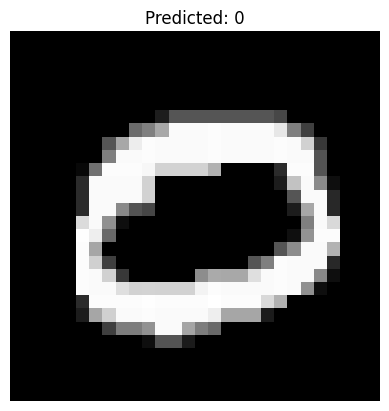

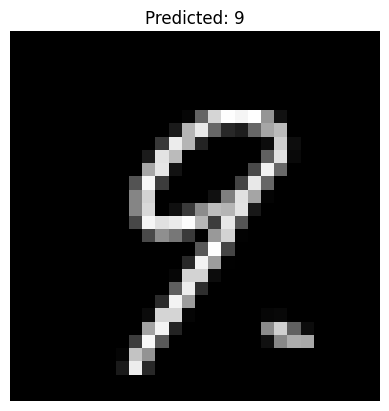

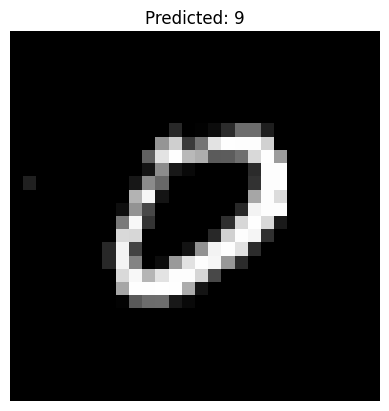

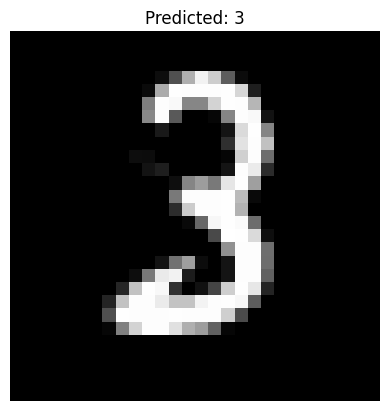

In [ ]:

#  VISUALIZE TEST PREDICTIONS

for i in range(5):
    image = X_test[i].reshape(28, 28)
    
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()

In [ ]:
# DISPLAY FINAL TRAINING ACCURACY

final_acc = history.history['accuracy'][-1]
final_loss = history.history['loss'][-1]

print("\nFinal Training Accuracy:", final_acc)
print("Final Training Loss:", final_loss)


Final Training Accuracy: 0.9931666851043701
Final Training Loss: 0.020227689296007156


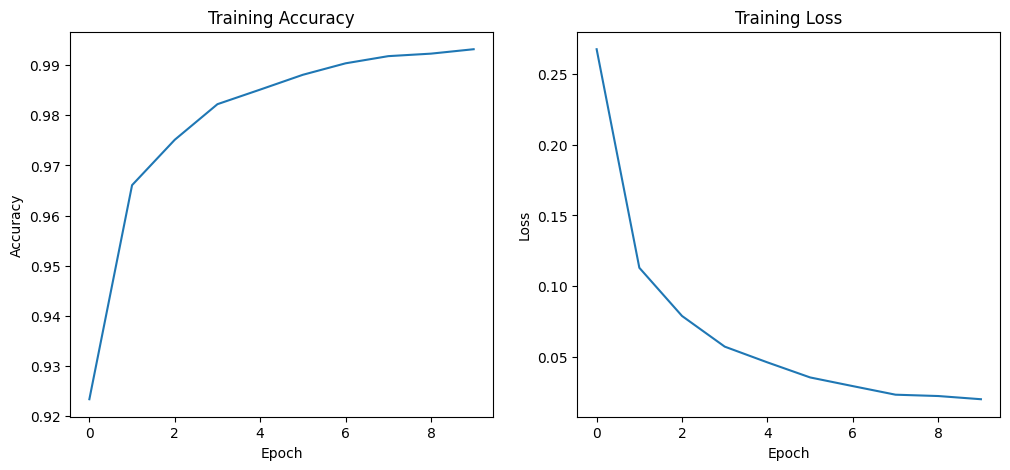

In [ ]:
# PLOT TRAINING ACCURACY & LOSS

plt.figure(figsize=(12, 5))

# ---- Accuracy Plot ----
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# ---- Loss Plot ----
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [ ]:
# SAVE TRAINED MODEL

model.save("mnist_mlp_model.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
# 
# LOAD SAVED MODEL

from tensorflow import keras

loaded_model = keras.models.load_model("mnist_mlp_model.h5")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
predictions = loaded_model.predict(X_test)

# Convert probabilities → labels
pred_labels = np.argmax(predictions, axis=1)

print("First 10 Predictions:")
print(pred_labels[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
First 10 Predictions:
[2 0 9 9 3 7 0 3 0 3]


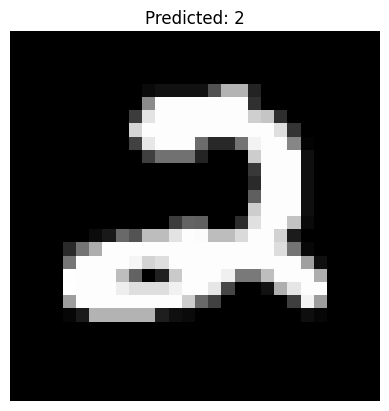

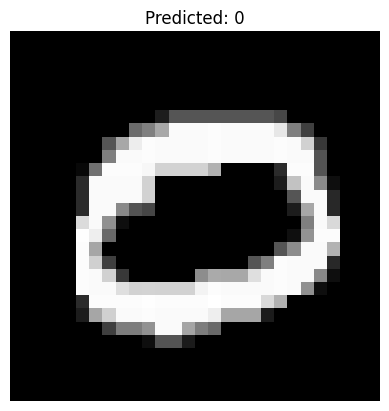

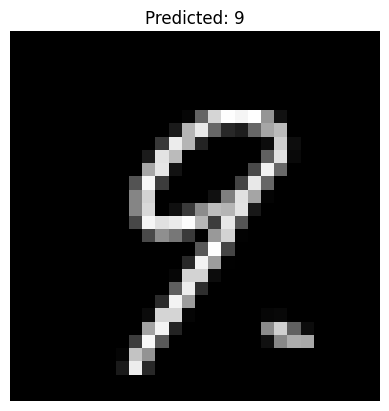

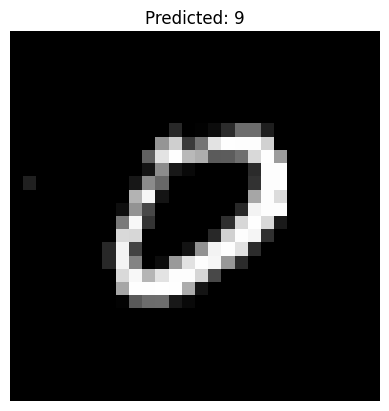

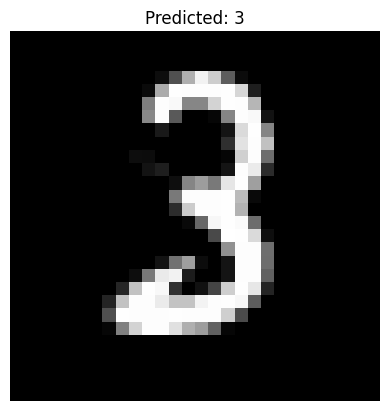

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    image = X_test[i].reshape(28, 28)
    
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()